In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

Libraries loaded. ✅


## 1 · Load and clean the raw data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
RAW = "yaleemmlc_admissionprediction_triage.csv"
DRIVE = "/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv"
path = DRIVE if os.path.exists(DRIVE) else RAW
df_raw = pd.read_csv(path)
print("Loaded", df_raw.shape[0], "rows and", df_raw.shape[1], "columns from:", path)
df_raw.head()

Loaded 55121 rows and 226 columns from: /content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Turns the raw, messy export into a modelling-ready table
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
df = df_raw.copy()

# Drop any stray index column (e.g. "Unnamed: 0") that pandas adds — it is not real data
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# 1) force the vitals to be NUMBERS; unparseable text (e.g. "120bpm") becomes NaN
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) the ESI label must be 1-5. Drop rows where it is missing or out of range —

df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# 3) blank out physically impossible vitals so they don't poison the model

df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# 4) encode gender to 0/1 (handles odd casings like "m" / "MALE")

df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

# 5) fill remaining missing NUMBERS with the column median (simple and defensible)

for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


## 2 · Choose the features (X) and the target (y)



In [5]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]
print("Model will use", len(FEATURES), "features. First few:", FEATURES[:6])

Model will use 208 features. First few: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device']


In [6]:
# Reproduce the EXACT Week 6 split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 44096 | test: 11025


In [7]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: sizes up the cc_other catch-all so you can judge it.
# (Skips safely if your extract doesn't include a cc_other column.)
# ------------------------------------------------------------------
if "cc_other" in df.columns:
    cc_cols = [c for c in df.columns if c.startswith("cc_")]
    total = len(df)
    has_other = int(df["cc_other"].sum())
    only_other = int(((df["cc_other"] == 1) & (df[cc_cols].sum(axis=1) == 1)).sum())
    print(f"Patients flagged cc_other: {has_other} of {total} ({has_other/total:.1%})")
    print(f"...and of those, patients whose ONLY complaint is 'other': {only_other}")
    print("\nMean ESI by cc_other flag (does 'other' lean urgent or not?):")
    print(df.groupby("cc_other")["esi"].mean().round(2))
else:
    print("No cc_other column in this sample — skipping. (On the full extract it will run.)")

Patients flagged cc_other: 4491 of 55121 (8.1%)
...and of those, patients whose ONLY complaint is 'other': 3352

Mean ESI by cc_other flag (does 'other' lean urgent or not?):
cc_other
0.0    2.87
1.0    3.01
2.0    3.26
3.0    3.00
Name: esi, dtype: float64


## 3 · The Week 6 baseline to beat

In [8]:
# Rebuilds the Week 6 baseline so we have a bar to clear.
baseline = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=42))
baseline.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, baseline.predict(X_test), average="macro")
print("Baseline (logistic regression) macro-F1:", round(baseline_f1, 3))

Baseline (logistic regression) macro-F1: 0.492


In [9]:
# Rebuilds the Week 6 Decision Tree baseline (the one that illustrated
# the class-imbalance failure: reasonable accuracy, 0% ESI-1 recall).
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
dt_baseline_f1 = f1_score(y_test, dt_baseline.predict(X_test), average="macro")
print("Baseline (decision tree) macro-F1:", round(dt_baseline_f1, 3))


Baseline (decision tree) macro-F1: 0.366


In [10]:
# Builds new clinical features from existing vitals,
# then applies them to BOTH the train and test sets in the same way.

def add_clinical_features(data):
    out = data.copy()

    # red-flag flags that do NOT use blood pressure:
    out["is_tachypneic"] = (out["triage_vital_rr"]   > 20     ).astype(int)  # fast breathing
    out["is_hypoxic"]    = (out["triage_vital_o2"]   < 92     ).astype(int)  # low oxygen
    out["is_febrile"]    = (out["triage_vital_temp"] >= 100.4 ).astype(int)  # fever
    out["is_bradycardic"] = (out["triage_vital_hr"]  < 60     ).astype(int)  # dangerously slow heart rate

    # stretch: a severity score = how many red flags fire
    out["red_flag_count"] = out[["is_tachypneic", "is_hypoxic", "is_febrile", "is_bradycardic"]].sum(axis=1)

    return out

X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)
print("Features after engineering:", X_train_fe.shape[1])
X_train_fe.head()


Features after engineering: 213


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,is_tachypneic,is_hypoxic,is_febrile,is_bradycardic,red_flag_count
35369,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1
52043,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
13610,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
54796,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
11096,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


## 6 · Model 1 — Random Forest



In [11]:
#Trains a random forest and shows which features it leaned on.

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train_fe, y_train)
rf_f1 = f1_score(y_test, rf.predict(X_test_fe), average="macro")
print("Random Forest macro-F1:", round(rf_f1, 3))

importances = pd.Series(rf.feature_importances_, index=X_train_fe.columns)
print("\nTop 10 features by importance:")
importances.sort_values(ascending=False).head(10)


Random Forest macro-F1: 0.426

Top 10 features by importance:


,0
triage_vital_sbp,0.104494
triage_vital_dbp,0.095919
triage_vital_hr,0.091544
triage_glucose,0.089513
triage_vital_temp,0.078795
triage_vital_o2,0.049282
triage_vital_rr,0.046856
cc_strokealert,0.042455
cc_abdominalpain,0.026852
triage_vital_o2_device,0.025964


In [12]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: turns the text demographic columns into numbers.
#   gender          -> already 0/1 from cleaning (binary needs one column)
#   age             -> already numeric
#   ethnicity, race -> ONE-HOT: one new 0/1 column per category
# ------------------------------------------------------------------
demo_1hot = pd.get_dummies(df[["ethnicity", "race"]], prefix=["eth", "race"], dtype=int)
print("New one-hot columns:", list(demo_1hot.columns))

def add_demographics(X_fe):
    """Bolt the encoded demographics onto an existing feature frame (aligned by row)."""
    rows = X_fe.index
    extra = demo_1hot.loc[rows].copy()
    extra["age"] = df.loc[rows, "age"]         # numeric already
    extra["gender"] = df.loc[rows, "gender"]   # 0/1 already
    return pd.concat([X_fe, extra], axis=1)

X_train_plus = add_demographics(X_train_fe)
X_test_plus = add_demographics(X_test_fe)
print("Features WITHOUT demographics:", X_train_fe.shape[1])
print("Features WITH    demographics:", X_train_plus.shape[1])
X_train_plus.filter(like="race_").head()

New one-hot columns: ['eth_Hispanic or Latino', 'eth_Non-Hispanic', 'eth_Patient Refused', 'eth_Unknown', 'race_American Indian or Alaska Native', 'race_Asian', 'race_Black or African American', 'race_Native Hawaiian or Other Pacific Islander', 'race_Other', 'race_Patient Refused', 'race_Unknown', 'race_White or Caucasian']
Features WITHOUT demographics: 213
Features WITH    demographics: 227


,race_American Indian or Alaska Native,race_Asian,race_Black or African American,race_Native Hawaiian or Other Pacific Islander,race_Other,race_Patient Refused,race_Unknown,race_White or Caucasian
35369,0,0,0,0,1,0,0,0
52043,0,0,0,0,0,0,0,1
13610,0,0,0,0,0,0,0,1
54796,0,0,1,0,0,0,0,0
11096,0,0,0,0,0,0,0,1


In [13]:
#Retrains the forest WITH the encoded demographics
# and compares it to the demographics-free version from Section 6.

rf_demo = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
rf_demo.fit(X_train_plus, y_train)
rf_demo_f1 = f1_score(y_test, rf_demo.predict(X_test_plus), average="macro")

print("Random Forest (no demographics) macro-F1:", round(rf_f1, 3))
print("Random Forest (with demographics) macro-F1:", round(rf_demo_f1, 3))
print("Difference:", round(rf_demo_f1 - rf_f1, 3))


Random Forest (no demographics) macro-F1: 0.426
Random Forest (with demographics) macro-F1: 0.43
Difference: 0.004


In [14]:
#Searches random-forest settings with 3-fold CV and
# keeps the combination that scores best on macro-F1.

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),  # no n_jobs here — avoids nested parallelism
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,   # parallelize at the search level instead
    verbose=1,   # prints progress as each fold/combo finishes
)
search.fit(X_train_fe, y_train)

print("Best params:", search.best_params_)
print("Best CV macro-F1:", round(search.best_score_, 3))

rf_tuned = search.best_estimator_
rf_tuned_f1 = f1_score(y_test, rf_tuned.predict(X_test_fe), average="macro")
print("Tuned Random Forest macro-F1 (held-out test set):", round(rf_tuned_f1, 3))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 200, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None}
Best CV macro-F1: 0.457
Tuned Random Forest macro-F1 (held-out test set): 0.476


## 9 · Model 2 — Gradient Boosting



In [15]:
#Trains a gradient-boosting model. No scaling needed.

hgb = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.1, max_iter=300,
    class_weight="balanced", random_state=42)
hgb.fit(X_train_fe, y_train)
hgb_f1 = f1_score(y_test, hgb.predict(X_test_fe), average="macro")
print("Gradient Boosting macro-F1:", round(hgb_f1, 3))

Gradient Boosting macro-F1: 0.437


## 10 · Model 3 — a small neural network (MLP)



In [16]:
#Trains a small neural network on SCALED features.

mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=500, random_state=42))
mlp.fit(X_train_fe, y_train)
mlp_f1 = f1_score(y_test, mlp.predict(X_test_fe), average="macro")
print("Small MLP macro-F1:", round(mlp_f1, 3))

Small MLP macro-F1: 0.426


## 13 · Save your tuned models

In [17]:
#Saves the models Tutorial 3 will benchmark.

joblib.dump(rf_tuned, "w7_random_forest.joblib")
joblib.dump(hgb, "w7_gradient_boosting.joblib")
joblib.dump(mlp, "w7_mlp.joblib")
print("Saved: w7_random_forest.joblib, w7_gradient_boosting.joblib, w7_mlp.joblib ✅")

Saved: w7_random_forest.joblib, w7_gradient_boosting.joblib, w7_mlp.joblib ✅


## 15 · Six-Axis Benchmark



In [18]:
# Times training + inference and scores accuracy,
# ESI-1 recall, and macro-F1 for every candidate model, on the same
# X_train_fe / X_test_fe used throughout this notebook.

from sklearn.metrics import accuracy_score, recall_score
from sklearn.base import clone

def benchmark_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = model.predict(X_te)
    infer_ms = (time.perf_counter() - t0) / len(X_te) * 1000  # per prediction

    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, preds), 3),
        "Recall ESI 1": round(recall_score(y_te, preds, labels=[1], average=None, zero_division=0)[0], 3),
        "Macro F1": round(f1_score(y_te, preds, average="macro"), 3),
        "Train (s)": round(train_time_s, 2),
        "Infer (ms/pred)": round(infer_ms, 3),
    }, model  # return the fitted model too, so we can reuse the best one for SHAP later

# fresh, unfitted copies so every model's training time is measured on equal footing
candidates = {
    "Baseline (LogReg)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "Baseline (Decision Tree)": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Random Forest (tuned)": clone(rf_tuned),
    "Gradient Boosting": clone(hgb),
    "Small MLP": clone(mlp),
}

results = []
fitted_models = {}
for name, model in candidates.items():
    row, fitted = benchmark_model(name, model, X_train_fe, y_train, X_test_fe, y_test)
    results.append(row)
    fitted_models[name] = fitted

benchmark_df = pd.DataFrame(results).set_index("Model")
benchmark_df

,Accuracy,Recall ESI 1,Macro F1,Train (s),Infer (ms/pred)
Model,,,,,
Baseline (LogReg),0.670,0.250,0.490,11.43,0.003
Baseline (Decision Tree),0.563,0.062,0.386,2.95,0.002
Random Forest,0.649,0.062,0.426,68.83,0.194
Random Forest (tuned),0.607,0.312,0.476,337.02,0.077
Gradient Boosting,0.561,0.438,0.437,14.61,0.026
Small MLP,0.638,0.062,0.426,381.20,0.005


In [19]:
#Adds the seventh, qualitative axis — interpretability —
#using the same High / Medium / Low scale.

interpretability = {
    "Baseline (LogReg)": "High",       # read the coefficients directly
    "Baseline (Decision Tree)": "High",  # trace the branches for a single prediction
    "Random Forest": "Medium",         # feature_importances_, but many trees vote
    "Random Forest (tuned)": "Medium",
    "Gradient Boosting": "Low",        # needs SHAP to explain a single prediction
    "Small MLP": "Low",                # needs SHAP; weights alone are not readable
}

benchmark_df["Explain"] = pd.Series(interpretability)
benchmark_df = benchmark_df[["Accuracy", "Recall ESI 1", "Macro F1", "Train (s)", "Infer (ms/pred)", "Explain"]]
benchmark_df.sort_values("Macro F1", ascending=False)

,Accuracy,Recall ESI 1,Macro F1,Train (s),Infer (ms/pred),Explain
Model,,,,,,
Baseline (LogReg),0.670,0.250,0.490,11.43,0.003,High
Random Forest (tuned),0.607,0.312,0.476,337.02,0.077,Medium
Gradient Boosting,0.561,0.438,0.437,14.61,0.026,Low
Random Forest,0.649,0.062,0.426,68.83,0.194,Medium
Small MLP,0.638,0.062,0.426,381.20,0.005,Low
Baseline (Decision Tree),0.563,0.062,0.386,2.95,0.002,High


## 16 · Confusion Matrix for Every Model



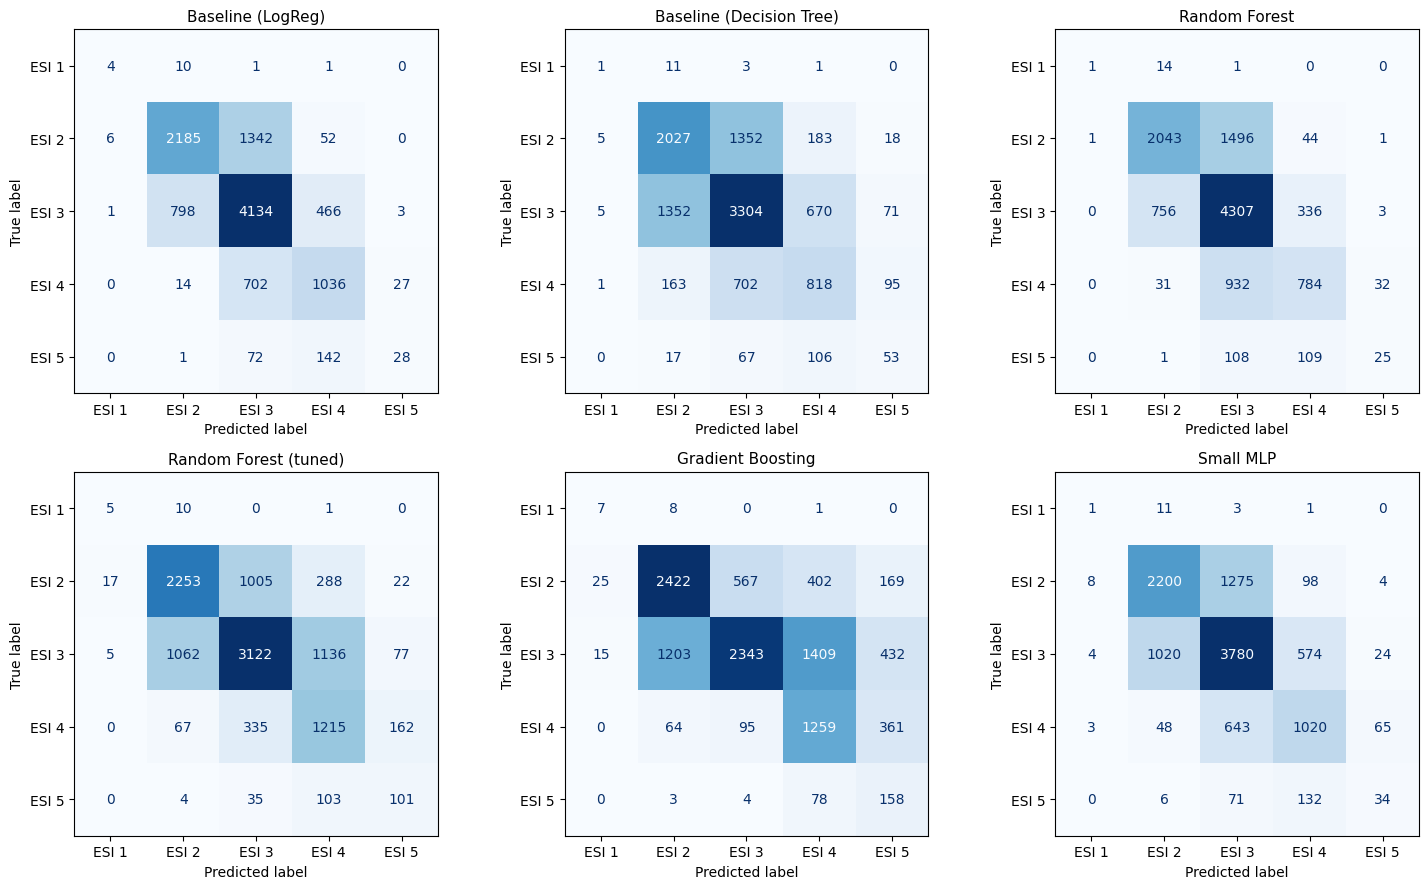

In [20]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: plots one confusion matrix per model, all on the
# same grid so they are easy to compare side by side. Reuses the fitted
# models from Section 15 (fitted_models), so no retraining happens here.
# ------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math

labels = sorted(y_test.unique())
model_names = list(fitted_models.keys())

n_models = len(model_names)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    model = fitted_models[name]
    preds = model.predict(X_test_fe)
    cm = confusion_matrix(y_test, preds, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f"ESI {l}" for l in labels])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name, fontsize=11)

# hide any unused subplot axes if the grid is bigger than the model count
for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()